# Decision Tree Classifier using CART

Down below I will be comparing the SKlearn decision tree classifier and my own using CART. I will then go into random forests and the ensemble etc.

In [11]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())
from minilearn.helper import ezcols
from minilearn.preprocessing.test_train_splitfunc import train_test_split
from minilearn.preprocessing.Scaler import StandardScalerMM


Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


In [12]:
features = pd.read_csv("data/processed/features.csv")

print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


In [13]:
feature_cols = ezcols()

X = features[feature_cols]
y = features["emotion"]

print(X.shape)
print(y.value_counts())

(2451, 480)
emotion
calm         376
happy        376
sad          376
angry        376
fearful      376
surprised    192
disgust      191
neutral      188
Name: count, dtype: int64


Down below is the diffence between my CART implementation and the one from SKLEARN. Below you will see I took a subset of the data. I did this because the amount of loops my python program has to go through recursilvely took this program 45 minutes to run. To help with the amount of time it took for demonstration purposes I had to take a subset of X and y for training. SKlearn is extremely quick at processing the infromation and I figured out its because it is using C to speed up the operations by many magnitudes. I think my implementation got a lower amount of score against SK-learn because I only did a max-depth of 5 again it is to save time so this dosent run forever. As you can see in the tree below Sklearn when far below a depth of 5.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from minilearn.classifiers.CART import CART
from minilearn.metrics.metricss import (
    accuracy,
    confusion_matrix,
    precision,
    recall,
    f1_score,
    plot_confusion_matrix,
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20, shuffle=True
)

scaler = StandardScalerMM()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

sample_idx = np.random.choice(len(X_train_scaled), size=500, replace=False)
X_train_sub = X_train_scaled[sample_idx]
y_train_sub = y_train[sample_idx]

skimodel = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=2, random_state=20)
minilearnmodel = CART(max_depth=5, minsplit=2)

skimodel.fit(X_train_sub, y_train_sub)
minilearnmodel.fit(X_train_sub, y_train_sub)

ski_pred = skimodel.predict(X_test_scaled)
mini_pred = minilearnmodel.predict(X_test_scaled)

print("MiniLearn train accuracy:", minilearnmodel.score(X_train_sub, y_train_sub))
print("MiniLearn test accuracy:", minilearnmodel.score(X_test_scaled, y_test))

print("Sklearn train accuracy:", skimodel.score(X_train_sub, y_train_sub))
print("Sklearn test accuracy:", skimodel.score(X_test_scaled, y_test))

classes = y.unique()
labels = classes.tolist()
class_names = labels


(1961, 480)
(490, 480)
MiniLearn train accuracy: 0.58
MiniLearn test accuracy: 0.26326530612244897
Sklearn train accuracy: 0.58
Sklearn test accuracy: 0.2836734693877551


So as you can see the CART algorithm is not very good on some many different features espeically just one tree. The tree is prioritizing the best splits but that does not mean it is picking ones that will generally be good for all new samples. In our train accuracy compared to the test accuracy you can see the tree is following trained examples instead of looking for actual patterns in the emotion features. To add on if the first couple of splits are bad then all future splits are also bad which is a big problem if your only using one tree which we are here. For the emotions the confusion matrix looks like someone threw darts at a dartboard it really dosent do a good job picking any emotions. By chance it seems to really of only gotten happy and calm

Sklearn Cart
Accuracy: 0.2836734693877551
Precision macro: 0.3353781391610339
Recall macro: 0.2912823305171048
F1 macro: 0.28042424490307316
F1 weighted: 0.2827813236278855


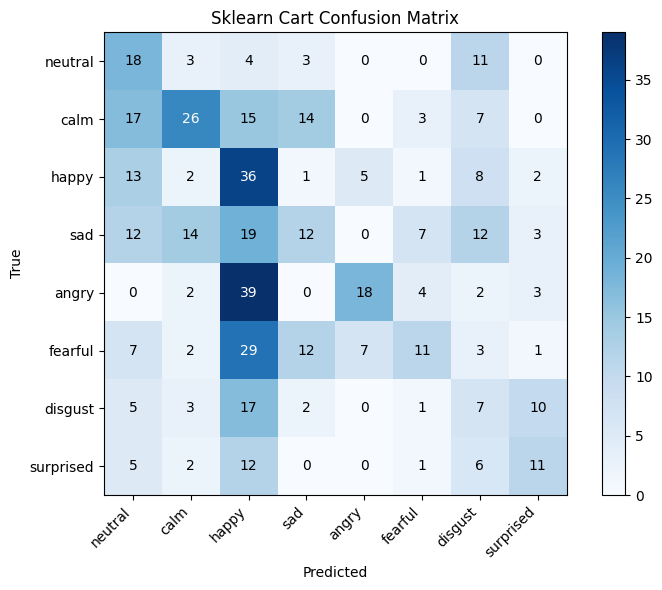

MiniLearn Cart
Accuracy: 0.26326530612244897
Precision macro: 0.27290699891156023
Recall macro: 0.274320465095407
F1 macro: 0.23716229588465187
F1 weighted: 0.2443581664589028


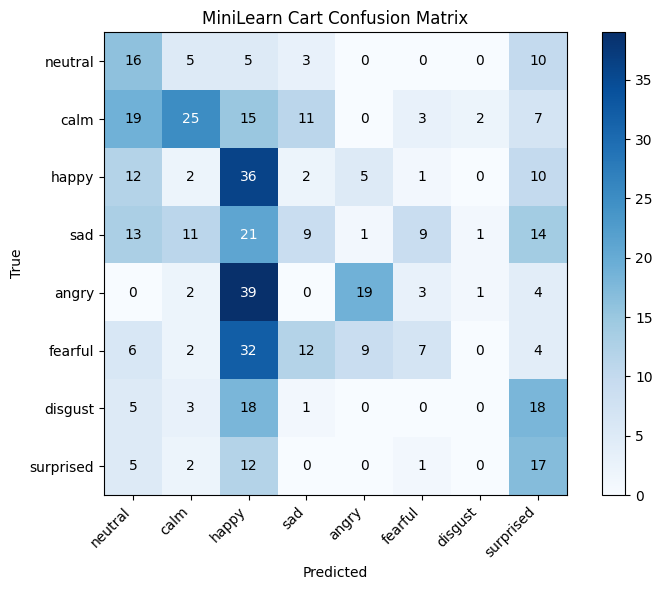

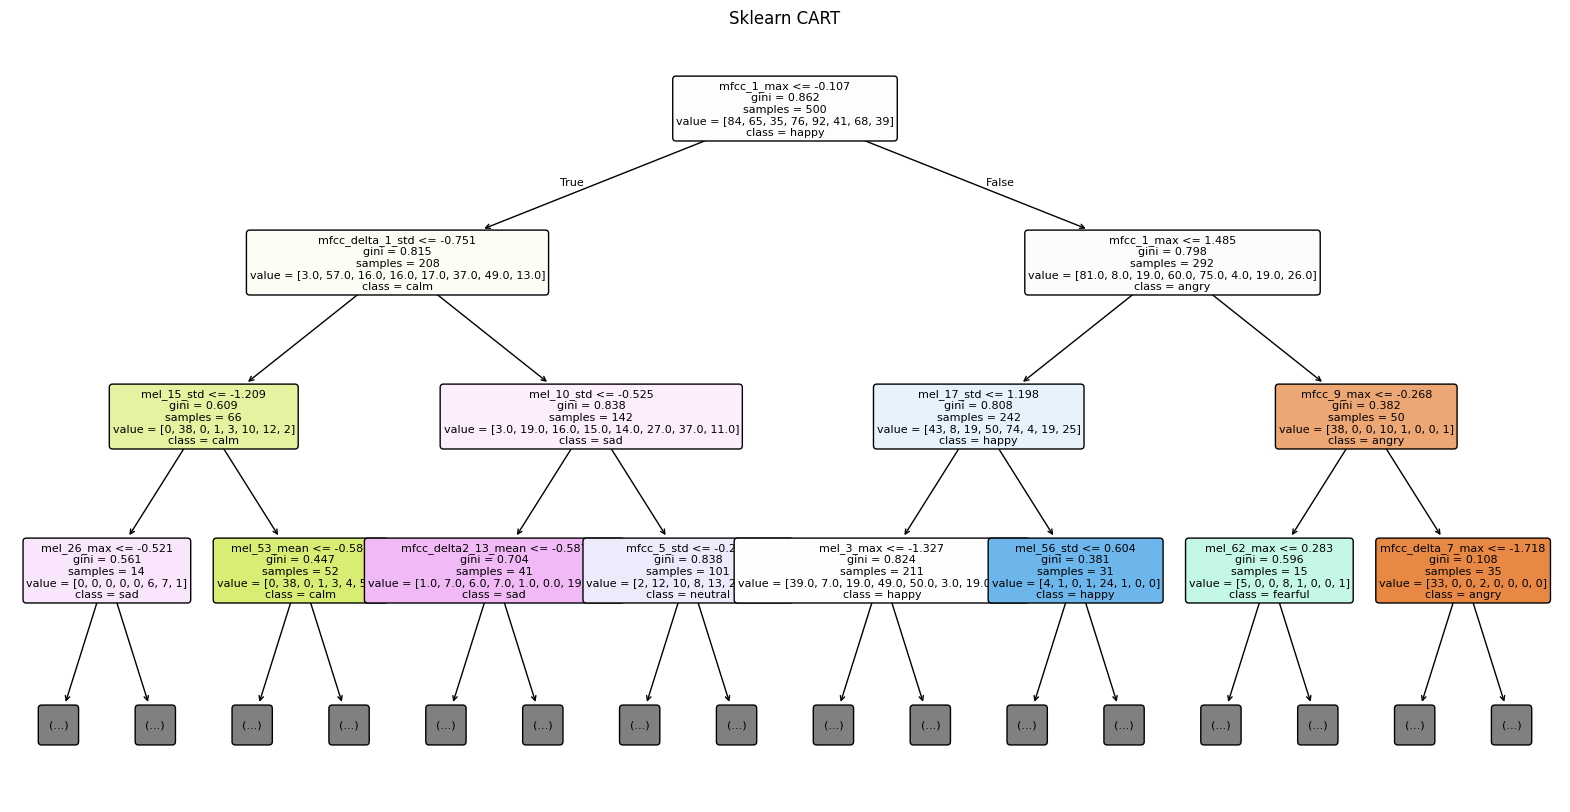

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

for model_name, preds in [
    ("Sklearn Cart", ski_pred),
    ("MiniLearn Cart", mini_pred)
]:
    print("=" * 50)
    print(model_name)
    print("Accuracy:", accuracy(y_test, preds))
    print("Precision macro:", precision(y_test, preds, labels))
    print("Recall macro:", recall(y_test, preds, labels))
    print("F1 macro:", f1_score(y_test, preds, labels))
    print("F1 weighted:", f1_score(y_test, preds, labels, average="weighted"))
    cm = confusion_matrix(y_test, preds, labels)
    plot_confusion_matrix(cm, class_names, title=f"{model_name} Confusion Matrix")

plt.figure(figsize=(20, 10))
plot_tree(skimodel, 
          filled=True, 
          max_depth=3,
          feature_names=feature_cols,
          class_names=skimodel.classes_,
          rounded=True,
          fontsize=8)
plt.title("Sklearn CART")
plt.show()